# 왜 금천구인가: 자치구 비교 EDA

분석 대상지를 금천구로 정한 근거를 자료로 확인한다. 서울 25개 자치구를 같은 기준으로 비교해 금천구가 어디에 위치하는지 보고, 구 안에서 수요와 공급이 어긋나는 지점을 찾는다.

확인할 질문은 넷이다.

1. 금천구의 무더위쉼터 공급은 다른 자치구와 비교해 어느 수준인가
2. 지정된 쉼터가 폭염 시간대와 주말에 실제로 열려 있는가
3. 쉼터로 쓸 수 있는 공공시설 재고는 얼마나 있는가
4. 주민등록인구로 설명되지 않는 주간 활동인구가 금천구에서 두드러지는가

산출물은 `2_데이터/가공/자치구별_지표.csv`와 `4_결과/대상지선정_EDA/`의 도판이다. 법정동별 집계는 노트북 안에서만 쓰고 파일로 남기지 않는다. 결과 해석은 `1_기획문서/04_대상지선정근거.md`에 정리한다.

사용 자료는 모두 로컬에 있는 공개 자료다. 서울시 무더위쉼터 현황, 서울시 경로당 현황, 서울시 공공도서관 현황, 소상공인시장진흥공단 상가(상권)정보다. 자치구별 인구는 별도 내려받기가 필요하며, 파일이 있으면 인구 대비 지표까지 계산하고 없으면 건너뛴다.

## 1. 설정

In [1]:
import re
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

BASE = Path.cwd().parent
RAW = BASE / "2_데이터" / "원본"
PROC = BASE / "2_데이터" / "가공"
SANGGA = RAW / "소상공인시장진흥공단_상가(상권)정보_서울_202606.csv"
FIG = BASE / "4_결과" / "대상지선정_EDA"
FIG.mkdir(parents=True, exist_ok=True)

TARGET = "금천구"

# 강조색 하나, 나머지는 회색. 계열이 둘인 그림에서만 두 번째 색을 쓴다.
C_HL, C_BG, C_ALT = "#2a78d6", "#c9c8c2", "#eb6834"
INK, MUTED = "#0b0b0b", "#52514e"


def barh(series, title, xlabel, fname, fmt="{:.0f}", highlight=TARGET):
    """자치구 가로막대. 대상 자치구만 색을 넣고 값을 직접 적는다."""
    s = series.sort_values()
    colors = [C_HL if i == highlight else C_BG for i in s.index]
    fig, ax = plt.subplots(figsize=(7, 7.5))
    bars = ax.barh(s.index, s.values, color=colors, height=0.72)
    for name, b in zip(s.index, bars):
        if name == highlight:
            ax.text(b.get_width() + s.max() * 0.012, b.get_y() + b.get_height() / 2,
                    fmt.format(s[name]), va="center", fontsize=9, color=INK)
    ax.set_title(title, fontsize=12, color=INK, pad=12)
    ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
    ax.tick_params(labelsize=9, colors=MUTED, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#dedcd5")
    ax.xaxis.grid(True, color="#ededea", linewidth=0.8)
    ax.set_axisbelow(True)
    plt.tight_layout()
    fig.savefig(FIG / fname, bbox_inches="tight", facecolor="white")
    plt.show()
    return s


def rank_text(series, name=TARGET, ascending=True):
    """'25개 구 중 N번째로 적음' 같은 문장을 만든다."""
    order = series.sort_values(ascending=ascending)
    pos = list(order.index).index(name) + 1
    word = "적" if ascending else "높"
    return f"{name}: {series[name]:,.1f} ({len(series)}개 구 중 {pos}번째로 {word}음, 중앙값 {series.median():,.1f})"

## 2. 자치구별 무더위쉼터 공급

서울시 무더위쉼터 원자료에서 주소로 자치구를 붙인다. 위치코드는 서울시 본청(1100000000)으로 등록된 시설이 있어 구 단위 집계에 쓰지 않는다.

운영시간은 두 가지로 본다. 폭염 피크 시간대는 평일 13~17시로 두고 이 구간을 통으로 여는 시설을 개방으로 센다. 자정을 넘겨 운영하는 시설은 종료시간에 24시간을 더해 보정한다.

In [2]:
sh = pd.read_csv(RAW / "서울시_무더위쉼터.csv", encoding="cp949", dtype=str)


def gu_of(row):
    for col in ("도로명주소", "지번주소"):
        m = re.search(r"서울특별시\s+(\S+구)", str(row[col]))
        if m:
            return m.group(1)
    return None


sh["자치구"] = sh.apply(gu_of, axis=1)
print("자치구 판별 실패:", sh["자치구"].isna().sum(), "/ 전체", len(sh))


def to_min(s):
    try:
        h, m = str(s).split(":")[:2]
        return int(h) * 60 + int(m)
    except (ValueError, AttributeError):
        return None


start = sh["기본운영_시작시간"].map(to_min)
end = sh["기본운영_종료시간"].map(to_min)
overnight = start.notna() & end.notna() & (end <= start)
end = end.where(~overnight, end + 24 * 60)

weekday = sh["기본운영_요일"].fillna("").apply(lambda s: bool({"월", "화", "수", "목", "금"} & set(str(s).split(","))))
weekend = sh["기본운영_요일"].fillna("").apply(lambda s: bool({"토", "일"} & set(str(s).split(","))))

sh["피크개방"] = weekday & start.notna() & end.notna() & (start <= 13 * 60) & (end >= 17 * 60)
sh["주말개방"] = weekend
sh["시설구분2"] = sh["시설구분2"].fillna("").str.replace("?", "·", regex=False)

gu = sh.groupby("자치구").agg(쉼터수=("쉼터명칭", "size"),
                            피크개방=("피크개방", "sum"),
                            주말개방=("주말개방", "sum"))
# 순위를 매길 때 동률이 생기지 않도록 반올림하지 않고 두고, 저장 직전에만 반올림한다.
gu["피크개방률"] = gu["피크개방"] / gu["쉼터수"] * 100
gu["주말개방률"] = gu["주말개방"] / gu["쉼터수"] * 100
print(rank_text(gu["쉼터수"]))
gu.sort_values("쉼터수").head(8)

자치구 판별 실패: 0 / 전체 4092


금천구: 104.0 (25개 구 중 7번째로 적음, 중앙값 153.0)


,쉼터수,피크개방,주말개방,피크개방률,주말개방률
자치구,,,,,
마포구,90,88,2,97.777778,2.222222
중구,90,54,12,60.000000,13.333333
강북구,97,97,1,100.000000,1.030928
강남구,98,71,0,72.448980,0.000000
광진구,100,98,1,98.000000,1.000000
용산구,101,100,17,99.009901,16.831683
금천구,104,91,11,87.500000,10.576923
동대문구,107,56,18,52.336449,16.822430


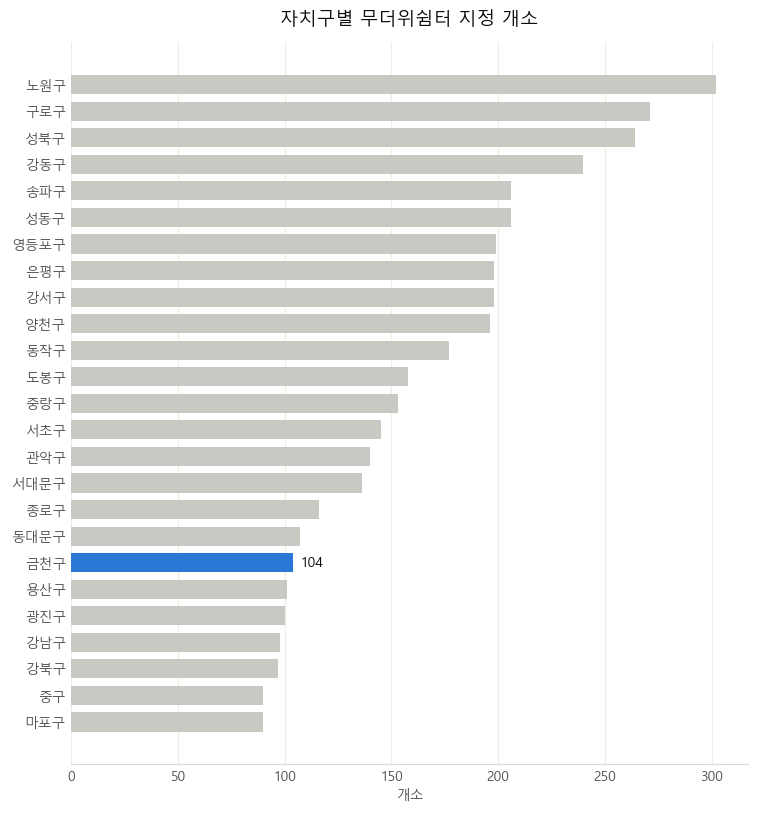

In [3]:
_ = barh(gu["쉼터수"], "자치구별 무더위쉼터 지정 개소", "개소", "01_자치구별_쉼터수.png")

## 3. 지정과 실제 개방의 차이

지정 개소 수와 폭염 시간대에 갈 수 있는 개소 수는 다르다. 두 지표를 나눠 본다.

금천구: 87.5 (25개 구 중 15번째로 높음, 중앙값 92.2)
금천구: 10.6 (25개 구 중 4번째로 높음, 중앙값 2.0)


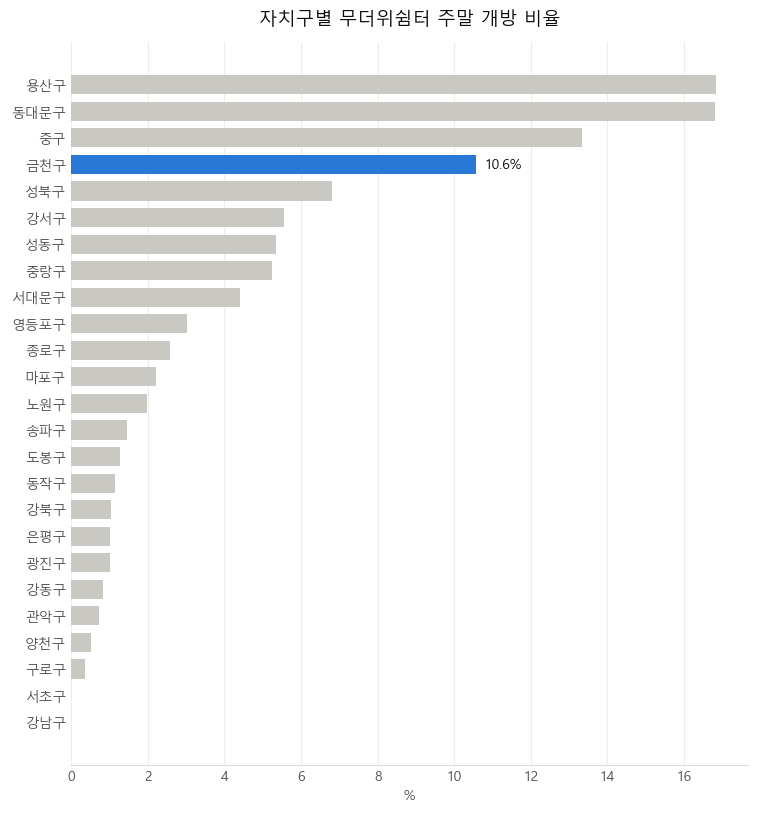

In [4]:
print(rank_text(gu["피크개방률"], ascending=False))
print(rank_text(gu["주말개방률"], ascending=False))
_ = barh(gu["주말개방률"], "자치구별 무더위쉼터 주말 개방 비율", "%", "02_자치구별_주말개방률.png", fmt="{:.1f}%")

In [5]:
# 금천구 쉼터를 유형별로 나눠 피크 개방률을 본다.
g_sh = sh[sh["자치구"] == TARGET]
tab = pd.crosstab(g_sh["시설구분1"], g_sh["피크개방"])
tab.columns = ["미개방", "개방"]
tab["개방률(%)"] = (tab["개방"] / tab.sum(axis=1) * 100).round(1)
tab

,미개방,개방,개방률(%)
시설구분1,,,
공공시설,1,37,97.4
생활밀착민간시설,11,4,26.7
특정계층이용시설,1,50,98.0


## 4. 쉼터로 쓸 수 있는 공공시설 재고

신규 쉼터는 대부분 기존 공공시설을 지정하는 방식이다. 후보가 될 시설이 얼마나 있는지가 입지 선택의 여지를 정한다. 경로당과 공공도서관 수로 재고를 가늠한다.

금천구: 78.0 (25개 구 중 3번째로 적음, 중앙값 145.0)
금천구: 4.0 (25개 구 중 1번째로 적음, 중앙값 9.0)


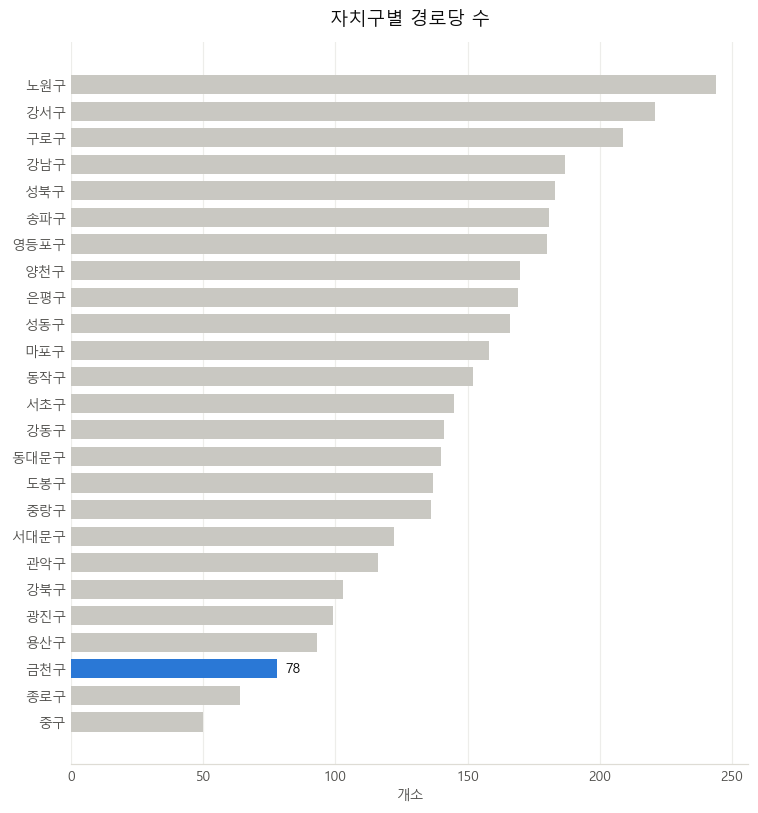

In [6]:
kd = pd.read_csv(RAW / "(서울시경로당)현황3644(25.6월말_기준)(2.csv", encoding="utf-8-sig",
                 header=None, dtype=str, skiprows=4).iloc[:, :7]
kd.columns = ["연번", "시도명", "시군구명", "시설종류", "시설명", "도로명", "관할"]
gu["경로당수"] = kd["시군구명"].str.strip().value_counts()

lib = pd.read_csv(RAW / "서울시_공공도서관_현황정보.csv", encoding="cp949", dtype=str)
gu["공공도서관수"] = lib["구명"].value_counts()

print(rank_text(gu["경로당수"]))
print(rank_text(gu["공공도서관수"]))
_ = barh(gu["경로당수"], "자치구별 경로당 수", "개소", "03_자치구별_경로당수.png")

## 5. 주민등록인구로 설명되지 않는 주간 활동인구

이 분석의 전제는 거주 인구와 주간 활동 인구가 다르다는 것이다. 유동인구 자료를 받기 전까지는 사업체 분포로 대신 본다. 소상공인 상가(상권)정보의 사업체 수와 업종 구성을 자치구별로 집계한다.

과학·기술 업종은 정보통신, 전문서비스 사업체가 들어가는 분류로, 이 비중이 높은 구는 주간에 일하러 들어오는 인구가 많다고 볼 수 있다.

서울 전체 파일은 크므로 20만 행씩 끊어 읽는다.

금천구: 33.7 (25개 구 중 2번째로 높음, 중앙값 12.2)
금천구: 18,353.0 (25개 구 중 13번째로 적음, 중앙값 18,353.0)


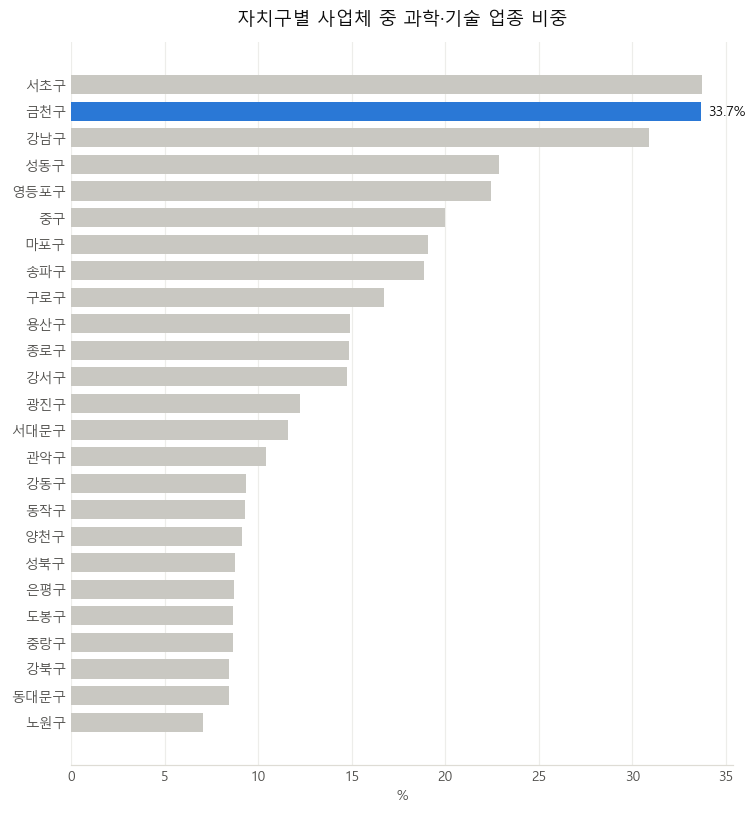

In [7]:

parts, dong_parts = [], []
for ch in pd.read_csv(SANGGA, dtype=str, chunksize=200_000,
                      usecols=["시군구명", "법정동명", "상권업종대분류명"], encoding="utf-8-sig"):
    parts.append(ch.groupby(["시군구명", "상권업종대분류명"]).size())
    g = ch[ch["시군구명"] == TARGET]
    if len(g):
        dong_parts.append(g.groupby(["법정동명", "상권업종대분류명"]).size())

biz = pd.concat(parts).groupby(level=[0, 1]).sum().unstack(fill_value=0)
dong_biz = pd.concat(dong_parts).groupby(level=[0, 1]).sum().unstack(fill_value=0)

gu["사업체수"] = biz.sum(axis=1)
gu["과학기술업종수"] = biz["과학·기술"]
gu["과학기술비중"] = gu["과학기술업종수"] / gu["사업체수"] * 100

print(rank_text(gu["과학기술비중"], ascending=False))
print(rank_text(gu["사업체수"]))
_ = barh(gu["과학기술비중"], "자치구별 사업체 중 과학·기술 업종 비중", "%",
         "04_자치구별_과학기술업종비중.png", fmt="{:.1f}%")


## 6. 인구 대비 지표 (선택)

자치구별 인구는 별도로 내려받아야 한다. 서울 열린데이터광장의 `서울시 주민등록인구 (연령별/구별) 통계`에서 최근 분기를 받아 자치구, 총인구, 65세 이상 인구 세 열만 남긴 뒤 `2_데이터/원본/자치구별_고령인구.csv`로 저장하면 아래 셀이 동작한다. 파일이 없으면 건너뛴다.

In [8]:
POP = RAW / "자치구별_고령인구.csv"

if POP.exists():
    pop = pd.read_csv(POP, dtype=str)
    pop.columns = [c.strip() for c in pop.columns]
    pop = pop.rename(columns={pop.columns[0]: "자치구"})
    for c in pop.columns[1:]:
        pop[c] = pd.to_numeric(pop[c].str.replace(",", ""), errors="coerce")
    pop = pop.set_index("자치구")
    gu["총인구"] = pop.iloc[:, 0]
    gu["고령인구"] = pop.iloc[:, 1]
    gu["고령화율"] = gu["고령인구"] / gu["총인구"] * 100
    gu["고령인구만명당_쉼터수"] = gu["쉼터수"] / gu["고령인구"] * 10_000
    print(rank_text(gu["고령인구만명당_쉼터수"]))
    _ = barh(gu["고령인구만명당_쉼터수"], "고령인구 1만 명당 무더위쉼터 개소", "개소",
             "05_자치구별_고령인구당_쉼터수.png", fmt="{:.1f}")
else:
    print("인구 파일이 없어 건너뛴다:", POP)
    print("서울 열린데이터광장 > 서울시 주민등록인구 (연령별/구별) 통계")
    print("https://data.seoul.go.kr/dataList/OA-12235/S/1/datasetView.do")

인구 파일이 없어 건너뛴다: C:\Users\USER\OneDrive\바탕 화면\공모전\shelter-location-mclp\2_데이터\원본\자치구별_고령인구.csv
서울 열린데이터광장 > 서울시 주민등록인구 (연령별/구별) 통계
https://data.seoul.go.kr/dataList/OA-12235/S/1/datasetView.do


## 7. 금천구 안에서의 수요와 공급 어긋남

자치구 사이 비교만으로는 왜 구 안에서 입지를 다시 정해야 하는지 설명되지 않는다. 금천구를 법정동 셋으로 나눠 활동 규모와 쉼터 공급을 대조한다.

In [9]:

DONGS = ["가산동", "독산동", "시흥동"]

shelters = pd.read_csv(PROC / "금천구_무더위쉼터.csv", dtype=str)
cand = pd.read_csv(PROC / "금천구_후보시설.csv", dtype=str)


def dong_of(text):
    for d in DONGS:
        if d in str(text):
            return d
    return "미상"


shelters["법정동"] = (shelters["도로명주소"].fillna("") + shelters["지번주소"].fillna("")).map(dong_of)
cand["법정동"] = cand["시구동"].map(dong_of)

inner = pd.DataFrame({
    "사업체수": dong_biz.sum(axis=1),
    "무더위쉼터": shelters["법정동"].value_counts(),
    "후보시설": cand["법정동"].value_counts(),
}).reindex(DONGS).fillna(0).astype(int)
inner["사업체비중"] = (inner["사업체수"] / inner["사업체수"].sum() * 100).round(1)
inner["쉼터비중"] = (inner["무더위쉼터"] / inner["무더위쉼터"].sum() * 100).round(1)
inner.index.name = "법정동"
inner


,사업체수,무더위쉼터,후보시설,사업체비중,쉼터비중
법정동,,,,,
가산동,10436,11,10,56.9,10.6
독산동,4242,47,43,23.1,45.2
시흥동,3675,46,49,20.0,44.2


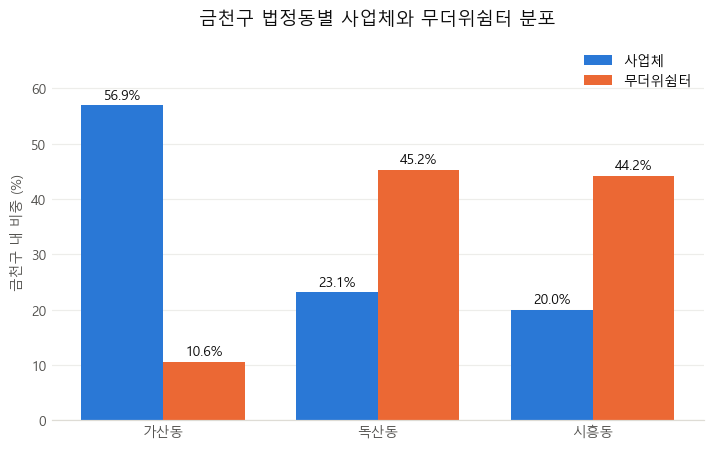

In [10]:
x = range(len(DONGS))
w = 0.38
fig, ax = plt.subplots(figsize=(6.6, 4.2))
b1 = ax.bar([i - w / 2 for i in x], inner["사업체비중"], width=w, color=C_HL, label="사업체")
b2 = ax.bar([i + w / 2 for i in x], inner["쉼터비중"], width=w, color=C_ALT, label="무더위쉼터")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.2, f"{b.get_height():.1f}%",
                ha="center", fontsize=9, color=INK)

ax.set_xticks(list(x))
ax.set_xticklabels(DONGS, fontsize=10, color=INK)
ax.set_ylabel("금천구 내 비중 (%)", fontsize=9, color=MUTED)
ax.set_title("금천구 법정동별 사업체와 무더위쉼터 분포", fontsize=12, color=INK, pad=12)
ax.set_ylim(0, max(inner["사업체비중"].max(), inner["쉼터비중"].max()) * 1.2)
ax.tick_params(labelsize=9, colors=MUTED, length=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#dedcd5")
ax.yaxis.grid(True, color="#ededea", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
fig.savefig(FIG / "06_금천구_법정동별_사업체와_쉼터.png", bbox_inches="tight", facecolor="white")
plt.show()

In [11]:

# 가산동에 몰린 업종을 확인한다.
gasan = dong_biz.loc["가산동"]
print("가산동 사업체", int(gasan.sum()), "개")
print((gasan / gasan.sum() * 100).round(1).sort_values(ascending=False).head(5).to_string())


가산동 사업체 10436 개
상권업종대분류명
과학·기술      51.3
소매         13.8
음식         13.7
시설관리·임대     7.3
부동산         4.2


## 8. 종합표 저장

In [12]:
cols = ["쉼터수", "피크개방", "피크개방률", "주말개방", "주말개방률",
        "경로당수", "공공도서관수", "사업체수", "과학기술업종수", "과학기술비중"]
cols += [c for c in ("총인구", "고령인구", "고령화율", "고령인구만명당_쉼터수") if c in gu.columns]

out = gu[cols].sort_values("쉼터수").round(1)
out.to_csv(PROC / "자치구별_지표.csv", encoding="utf-8-sig")
print("저장:", (PROC / "자치구별_지표.csv").resolve())
out.loc[[TARGET]].T

저장: C:\Users\USER\OneDrive\바탕 화면\공모전\shelter-location-mclp\2_데이터\가공\자치구별_지표.csv


자치구,금천구
쉼터수,104.0
피크개방,91.0
피크개방률,87.5
주말개방,11.0
주말개방률,10.6
경로당수,78.0
공공도서관수,4.0
사업체수,18353.0
과학기술업종수,6176.0
과학기술비중,33.7


## 9. 정리

여기서 나온 수치는 `1_기획문서/04_대상지선정근거.md`에 문장으로 옮긴다. 유동인구 자료를 확보하면 5절의 사업체 대리지표를 60대 이상 유동인구로 교체하고, 6절의 인구 대비 지표를 다시 계산한다. 그때 사업체 비중과 유동인구 분포가 같은 방향을 가리키는지 확인하면 대리지표의 타당성도 함께 검증된다.